In [1]:
!pip install inference-sdk

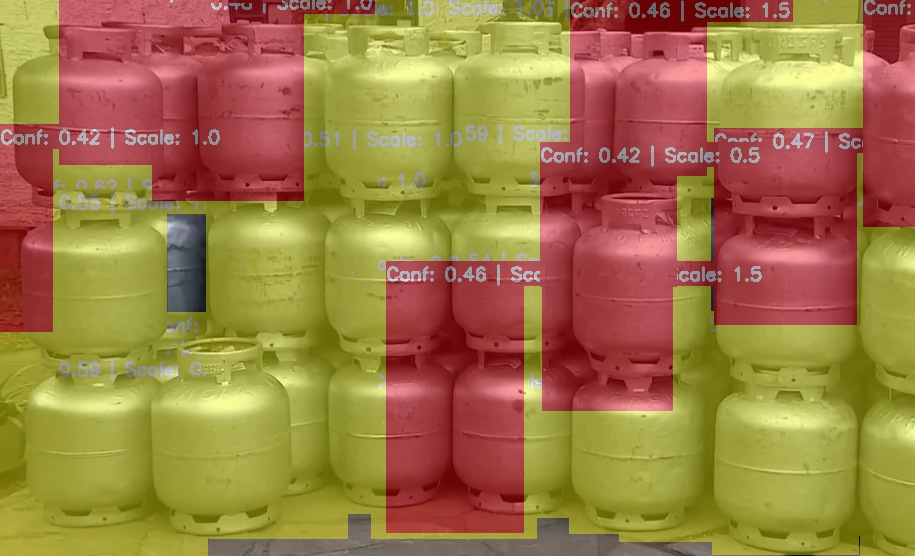

In [2]:
from inference_sdk import InferenceHTTPClient
import cv2
import numpy as np
from datetime import datetime
import os
from typing import Dict, List, Tuple, Optional
import json
from google.colab.patches import cv2_imshow  # Adicionado para exibir imagens no Colab

class EnhancedObjectDetector:
    def __init__(self, api_key: str, api_url: str = "https://detect.roboflow.com"):
        """Initialize the enhanced object detector with API credentials."""
        self.client = InferenceHTTPClient(
            api_url=api_url,
            api_key=api_key
        )
        self.detection_history = []

    def load_image(self, image_path: str) -> np.ndarray:
        """Load and verify image from path."""
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Error: Could not load image at {image_path}")
        return image

    def enhance_image(self, image: np.ndarray) -> List[np.ndarray]:
        """Gera múltiplas versões melhoradas da imagem para detecção robusta"""
        enhanced_images = [image.copy()]

        # 1. Variações de brilho e contraste
        contrast_params = [0.5, 0.8, 1.0, 1.2, 1.5]
        brightness_params = [-50, -30, 0, 30, 50]

        for alpha in contrast_params:
            for beta in brightness_params:
                adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
                enhanced_images.append(adjusted)

        # 2. Conversões de espaço de cores
        color_conversions = [
            (cv2.COLOR_BGR2HSV, cv2.COLOR_HSV2BGR),
            (cv2.COLOR_BGR2LAB, cv2.COLOR_LAB2BGR),
            (cv2.COLOR_BGR2YUV, cv2.COLOR_YUV2BGR),
            (cv2.COLOR_BGR2HLS, cv2.COLOR_HLS2BGR)
        ]

        for conversion, inverse in color_conversions:
            try:
                converted = cv2.cvtColor(image, conversion)
                reconverted = cv2.cvtColor(converted, inverse)
                enhanced_images.append(reconverted)
            except cv2.error as e:
                print(f"Conversão de cores falhou: {conversion}->{inverse}: {str(e)}")
                continue

        # 3. Redução de ruído
        try:
            denoised_soft = cv2.fastNlMeansDenoisingColored(image, h=3, hColor=10)
            denoised_strong = cv2.fastNlMeansDenoisingColored(image, h=7, hColor=15)
            enhanced_images.extend([denoised_soft, denoised_strong])
        except cv2.error as e:
            print(f"Denoising falhou: {str(e)}")

        # 4. Equalização de histograma adaptativo (CLAHE)
        try:
            lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
            l_channel, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
            l_clahe = clahe.apply(l_channel)
            merged = cv2.merge((l_clahe, a, b))
            clahe_image = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
            enhanced_images.append(clahe_image)
        except Exception as e:
            print(f"CLAHE falhou: {str(e)}")

        # 5. Transformações geométricas
        angles = [0, 90, 180, 270]
        for angle in angles:
            try:
                if angle != 0:
                    center = (image.shape[1]//2, image.shape[0]//2)
                    M = cv2.getRotationMatrix2D(center, angle, 1.0)
                    rotated = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))
                    enhanced_images.append(rotated)
            except Exception as e:
                print(f"Rotação {angle}° falhou: {str(e)}")

        # Flip horizontal e vertical
        enhanced_images.append(cv2.flip(image, 1))  # Horizontal
        enhanced_images.append(cv2.flip(image, 0))  # Vertical

        # 6. Nitidez e realce de bordas
        try:
            kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
            sharpened = cv2.filter2D(image, -1, kernel)
            enhanced_images.append(sharpened)
        except Exception as e:
            print(f"Sharpening falhou: {str(e)}")

        # Verificação final
        valid_images = []
        for img in enhanced_images:
            if len(img.shape) == 3 and img.shape[2] == 3:
                valid_images.append(img)
            else:
                try:
                    fixed_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
                    valid_images.append(fixed_img)
                except:
                    print("Imagem inválida descartada")

        return valid_images

    def apply_multi_scale_detection(self, image: np.ndarray, model_id: str) -> List[Dict]:
        """Apply detection at multiple scales."""
        predictions = []
        scales = [0.5, 1.0, 1.5, 2.0]

        for scale in scales:
            if scale != 1.0:
                width = int(image.shape[1] * scale)
                height = int(image.shape[0] * scale)
                scaled_image = cv2.resize(image, (width, height))
            else:
                scaled_image = image

            # Save temporary image for inference
            temp_path = f"temp_scaled_{scale}.jpg"
            cv2.imwrite(temp_path, scaled_image)

            try:
                result = self.client.infer(temp_path, model_id=model_id)
                # Adjust coordinates back to original scale
                for pred in result["predictions"]:
                    pred["x"] = pred["x"] / scale
                    pred["y"] = pred["y"] / scale
                    pred["width"] = pred["width"] / scale
                    pred["height"] = pred["height"] / scale
                    pred["scale"] = scale
                predictions.extend(result["predictions"])
            except Exception as e:
                print(f"Error during detection at scale {scale}: {str(e)}")

            # Clean up temporary file
            if os.path.exists(temp_path):
                os.remove(temp_path)

        return predictions

    def non_max_suppression(self, predictions: List[Dict], iou_threshold: float = 0.5) -> List[Dict]:
        """Apply non-maximum suppression to remove overlapping detections."""
        if not predictions:
            return []

        # Convert predictions to format suitable for NMS
        boxes = []
        scores = []
        for pred in predictions:
            x1 = int(pred["x"] - pred["width"] / 2)
            y1 = int(pred["y"] - pred["height"] / 2)
            x2 = int(pred["x"] + pred["width"] / 2)
            y2 = int(pred["y"] + pred["height"] / 2)
            boxes.append([x1, y1, x2, y2])
            scores.append(pred["confidence"])

        boxes = np.array(boxes)
        scores = np.array(scores)

        # Compute areas
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

        # Sort by confidence
        order = scores.argsort()[::-1]

        keep = []
        while order.size > 0:
            i = order[0]
            keep.append(i)

            # Compute IoU
            xx1 = np.maximum(boxes[i, 0], boxes[order[1:], 0])
            yy1 = np.maximum(boxes[i, 1], boxes[order[1:], 1])
            xx2 = np.minimum(boxes[i, 2], boxes[order[1:], 2])
            yy2 = np.minimum(boxes[i, 3], boxes[order[1:], 3])

            w = np.maximum(0.0, xx2 - xx1)
            h = np.maximum(0.0, yy2 - yy1)
            inter = w * h

            ovr = inter / (areas[i] + areas[order[1:]] - inter)

            inds = np.where(ovr <= iou_threshold)[0]
            order = order[inds + 1]

        return [predictions[i] for i in keep]

    def draw_detections(self, image: np.ndarray, predictions: List[Dict],
                       confidence_threshold: float = 0.3) -> Tuple[np.ndarray, List[Dict]]:
        """Draw bounding boxes and labels on detected objects."""
        detected_objects = []
        overlay = image.copy()

        # Sort predictions by confidence
        predictions.sort(key=lambda x: x["confidence"], reverse=True)

        for prediction in predictions:
            confidence = prediction["confidence"]
            if confidence < confidence_threshold:
                continue

            # Extract coordinates
            x = int(prediction["x"])
            y = int(prediction["y"])
            width = int(prediction["width"])
            height = int(prediction["height"])

            # Calculate box coordinates
            x1 = max(0, int(x - width / 2))
            y1 = max(0, int(y - height / 2))
            x2 = min(image.shape[1], int(x + width / 2))
            y2 = min(image.shape[0], int(y + height / 2))

            # Generate color based on confidence
            color = self._get_confidence_color(confidence)

            # Draw filled rectangle with transparency
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)

            # Add detection info
            detected_objects.append({
                "confidence": confidence,
                "bbox": (x1, y1, x2, y2),
                "scale": prediction.get("scale", 1.0)
            })

            # Add label with confidence and scale
            label = f"Conf: {confidence:.2f} | Scale: {prediction.get('scale', 1.0):.1f}"
            self._draw_label(overlay, label, (x1, y1), color)

        # Blend the overlay with the original image
        alpha = 0.4
        cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0, image)

        return image, detected_objects

    def _get_confidence_color(self, confidence: float) -> Tuple[int, int, int]:
        """Generate color based on confidence level."""
        if confidence > 0.8:
            return (0, 255, 0)    # Green for high confidence
        elif confidence > 0.5:
            return (0, 255, 255)  # Yellow for medium confidence
        else:
            return (0, 0, 255)    # Red for low confidence

    def _draw_label(self, image: np.ndarray, label: str, pos: Tuple[int, int],
                   color: Tuple[int, int, int]) -> None:
        """Draw label with background on image."""
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness = 2

        # Get label size
        (label_w, label_h), _ = cv2.getTextSize(label, font, font_scale, thickness)

        # Draw background rectangle
        cv2.rectangle(image, pos, (pos[0] + label_w, pos[1] - label_h - 10), color, -1)

        # Draw text
        cv2.putText(image, label, (pos[0], pos[1] - 5), font, font_scale, (255, 255, 255), thickness)

    def process_image(self, image_path: str, model_id: str,
                     confidence_threshold: float = 0.3,
                     save_output: bool = True) -> Tuple[np.ndarray, Dict]:
        """Process image with enhanced detection capabilities."""
        try:
            # Load image
            original_image = self.load_image(image_path)

            # Create enhanced versions of the image
            enhanced_images = self.enhance_image(original_image)

            all_predictions = []
            for idx, img in enumerate(enhanced_images):
                # Apply multi-scale detection
                predictions = self.apply_multi_scale_detection(img, model_id)
                all_predictions.extend(predictions)

            # Apply non-max suppression to remove duplicates
            filtered_predictions = self.non_max_suppression(all_predictions)

            # Draw detections on original image
            result_image, detections = self.draw_detections(
                original_image.copy(),
                filtered_predictions,
                confidence_threshold
            )

            # Save results
            if save_output:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                output_dir = "enhanced_detection_results"
                os.makedirs(output_dir, exist_ok=True)

                # Save image with detections
                output_path = os.path.join(output_dir, f"detected_{timestamp}.jpg")
                cv2.imwrite(output_path, result_image)

                # Save detection data
                data_path = os.path.join(output_dir, f"detections_{timestamp}.json")
                with open(data_path, 'w') as f:
                    json.dump({
                        'total_detections': len(detections),
                        'detections': detections,
                        'image_size': original_image.shape[:2],
                        'timestamp': timestamp
                    }, f, indent=4)

            # Prepare summary
            summary = {
                "total_detections": len(detections),
                "detections": detections,
                "output_path": output_path if save_output else None,
                "data_path": data_path if save_output else None,
                "image_size": original_image.shape[:2]
            }

            return result_image, summary

        except Exception as e:
            raise Exception(f"Error processing image: {str(e)}")

def main():
    # Configuration
    API_KEY = "1uaBIxC6yfhPjoHi8YF3"  # Replace with your API key
    MODEL_ID = "garrafas-khs2q/1"
    IMAGE_PATH = "/content/fswefsdf.png"  # Replace with your image path

    # Initialize enhanced detector
    detector = EnhancedObjectDetector(api_key=API_KEY)

    try:
        # Process image with enhanced detection
        result_image, summary = detector.process_image(
            image_path=IMAGE_PATH,
            model_id=MODEL_ID,
            confidence_threshold=0.3  # Lower threshold to detect more objects
        )

        # Display results
        cv2_imshow(result_image)  # Usando cv2_imshow no lugar de cv2.imshow

        # Print detection summary
        print("\n=== Enhanced Detection Summary ===")
        print(f"Total objects detected: {summary['total_detections']}")
        print(f"Image size: {summary['image_size'][0]}x{summary['image_size'][1]}")

        if summary['output_path']:
            print(f"\nOutput saved to:")
            print(f"- Image: {summary['output_path']}")
            print(f"- Data: {summary['data_path']}")

        print("\nDetections by confidence level:")
        high_conf = len([d for d in summary['detections'] if d['confidence'] > 0.8])
        med_conf = len([d for d in summary['detections'] if 0.5 < d['confidence'] <= 0.8])
        low_conf = len([d for d in summary['detections'] if d['confidence'] <= 0.5])

        print(f"- High confidence (>0.8): {high_conf}")
        print(f"- Medium confidence (0.5-0.8): {med_conf}")
        print(f"- Low confidence (<=0.5): {low_conf}")

    except Exception as e:
        print(f"Error: {str(e)}")

if __name__ == "__main__":
    main()


=== Enhanced Detection Summary ===
Total objects detected: 42
Image size: 556x915

Output saved to:
- Image: enhanced_detection_results/detected_20250212_221243.jpg
- Data: enhanced_detection_results/detections_20250212_221243.json

Detections by confidence level:
- High confidence (>0.8): 0
- Medium confidence (0.5-0.8): 33
- Low confidence (<=0.5): 9


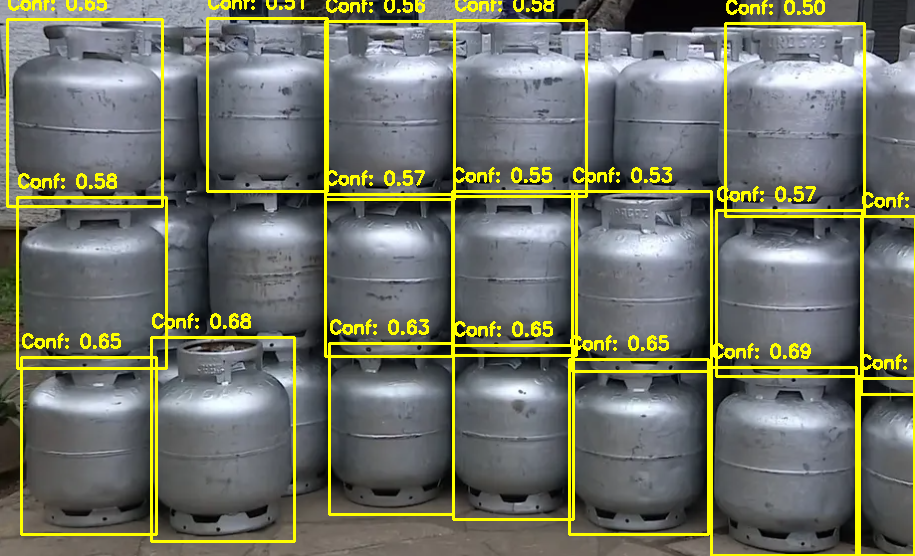


=== Resumo da Detecção ===
Total de objetos detectados: 18
Tamanho da imagem: 556x915

Resultados salvos em:
- Imagem: detection_results/detected_20250212_221243.jpg
- Dados: detection_results/detections_20250212_221243.json

Distribuição de confiança:
- Alta confiança (>0.8): 0
- Média confiança (0.5-0.8): 18
- Baixa confiança (<=0.5): 0


In [3]:
from inference_sdk import InferenceHTTPClient
import cv2
import numpy as np
from datetime import datetime
import os
import json
from google.colab.patches import cv2_imshow  # Para exibir imagens no Colab

class SimpleObjectDetector:
    def __init__(self, api_key: str, api_url: str = "https://detect.roboflow.com"):
        """Inicializa o detector de objetos com credenciais da API."""
        self.client = InferenceHTTPClient(api_url=api_url, api_key=api_key)

    def load_image(self, image_path: str) -> np.ndarray:
        """Carrega e verifica a imagem a partir do caminho."""
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Erro: Não foi possível carregar a imagem em {image_path}")
        return image

    def detect_objects(self, image: np.ndarray, model_id: str) -> List[Dict]:
        """Realiza a detecção de objetos na imagem."""
        # Salva a imagem temporariamente para inferência
        temp_path = "temp_image.jpg"
        cv2.imwrite(temp_path, image)

        try:
            # Realiza a inferência
            result = self.client.infer(temp_path, model_id=model_id)
            return result["predictions"]
        except Exception as e:
            print(f"Erro durante a detecção: {str(e)}")
            return []
        finally:
            # Remove o arquivo temporário
            if os.path.exists(temp_path):
                os.remove(temp_path)

    def draw_detections(self, image: np.ndarray, predictions: List[Dict],
                        confidence_threshold: float = 0.5) -> Tuple[np.ndarray, List[Dict]]:
        """Desenha caixas delimitadoras e rótulos nos objetos detectados."""
        detected_objects = []
        for prediction in predictions:
            confidence = prediction["confidence"]
            if confidence < confidence_threshold:
                continue

            # Extrai as coordenadas
            x = int(prediction["x"])
            y = int(prediction["y"])
            width = int(prediction["width"])
            height = int(prediction["height"])

            # Calcula as coordenadas da caixa delimitadora
            x1 = max(0, int(x - width / 2))
            y1 = max(0, int(y - height / 2))
            x2 = min(image.shape[1], int(x + width / 2))
            y2 = min(image.shape[0], int(y + height / 2))

            # Gera uma cor com base na confiança
            color = (0, 255, 0) if confidence > 0.8 else (0, 255, 255) if confidence > 0.5 else (0, 0, 255)

            # Desenha a caixa delimitadora
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

            # Adiciona o rótulo com a confiança
            label = f"Conf: {confidence:.2f}"
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Adiciona a detecção à lista
            detected_objects.append({
                "confidence": confidence,
                "bbox": (x1, y1, x2, y2)
            })

        return image, detected_objects

    def process_image(self, image_path: str, model_id: str,
                      confidence_threshold: float = 0.5,
                      save_output: bool = True) -> Tuple[np.ndarray, Dict]:
        """Processa a imagem e detecta objetos."""
        try:
            # Carrega a imagem
            original_image = self.load_image(image_path)

            # Realiza a detecção de objetos
            predictions = self.detect_objects(original_image, model_id)

            # Desenha as detecções na imagem
            result_image, detections = self.draw_detections(
                original_image.copy(),
                predictions,
                confidence_threshold
            )

            # Salva os resultados
            if save_output:
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                output_dir = "detection_results"
                os.makedirs(output_dir, exist_ok=True)

                # Salva a imagem com as detecções
                output_path = os.path.join(output_dir, f"detected_{timestamp}.jpg")
                cv2.imwrite(output_path, result_image)

                # Salva os dados das detecções
                data_path = os.path.join(output_dir, f"detections_{timestamp}.json")
                with open(data_path, 'w') as f:
                    json.dump({
                        'total_detections': len(detections),
                        'detections': detections,
                        'image_size': original_image.shape[:2],
                        'timestamp': timestamp
                    }, f, indent=4)

            # Prepara o resumo
            summary = {
                "total_detections": len(detections),
                "detections": detections,
                "output_path": output_path if save_output else None,
                "data_path": data_path if save_output else None,
                "image_size": original_image.shape[:2]
            }

            return result_image, summary

        except Exception as e:
            raise Exception(f"Erro ao processar a imagem: {str(e)}")

def main():
    # Configuração
    API_KEY = "1uaBIxC6yfhPjoHi8YF3"  # Substitua pela sua chave de API
    MODEL_ID = "garrafas-khs2q/1"      # Substitua pelo ID do seu modelo
    IMAGE_PATH = "/content/fswefsdf.png"  # Substitua pelo caminho da sua imagem

    # Inicializa o detector
    detector = SimpleObjectDetector(api_key=API_KEY)

    try:
        # Processa a imagem
        result_image, summary = detector.process_image(
            image_path=IMAGE_PATH,
            model_id=MODEL_ID,
            confidence_threshold=0.5  # Limiar de confiança
        )

        # Exibe os resultados
        cv2_imshow(result_image)  # Usando cv2_imshow no lugar de cv2.imshow

        # Exibe o resumo das detecções
        print("\n=== Resumo da Detecção ===")
        print(f"Total de objetos detectados: {summary['total_detections']}")
        print(f"Tamanho da imagem: {summary['image_size'][0]}x{summary['image_size'][1]}")

        if summary['output_path']:
            print(f"\nResultados salvos em:")
            print(f"- Imagem: {summary['output_path']}")
            print(f"- Dados: {summary['data_path']}")

        # Distribuição de confiança
        high_conf = len([d for d in summary['detections'] if d['confidence'] > 0.8])
        med_conf = len([d for d in summary['detections'] if 0.5 < d['confidence'] <= 0.8])
        low_conf = len([d for d in summary['detections'] if d['confidence'] <= 0.5])

        print("\nDistribuição de confiança:")
        print(f"- Alta confiança (>0.8): {high_conf}")
        print(f"- Média confiança (0.5-0.8): {med_conf}")
        print(f"- Baixa confiança (<=0.5): {low_conf}")

    except Exception as e:
        print(f"Erro: {str(e)}")

if __name__ == "__main__":
    main()

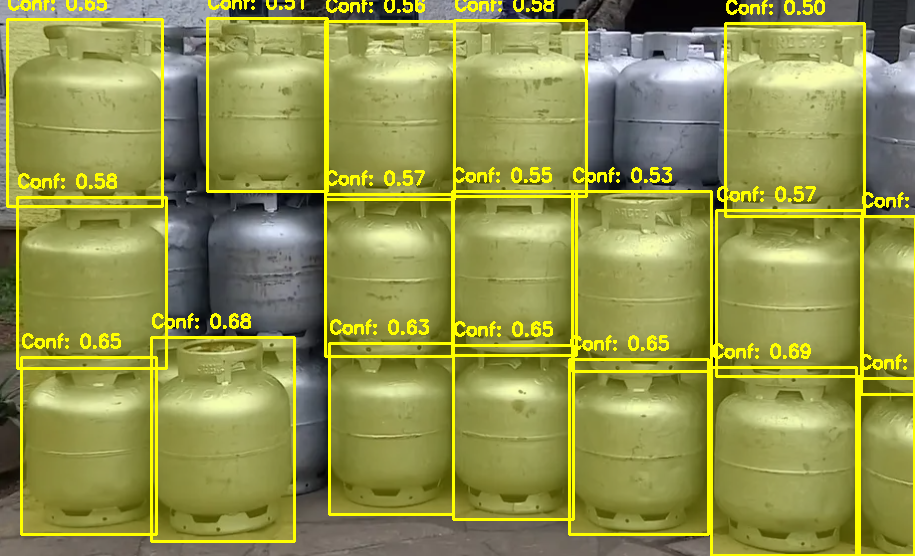


=== Resumo da Detecção ===
Total de objetos detectados: 18

Resultados salvos em:
- Imagem: detection_results/detected_20250212_221244.jpg
- Dados: detection_results/detections_20250212_221244.json


In [4]:
from inference_sdk import InferenceHTTPClient
import cv2
import numpy as np
from datetime import datetime
import os
import json
from google.colab.patches import cv2_imshow

class SimpleObjectDetector:
    def __init__(self, api_key: str, api_url: str = "https://detect.roboflow.com"):
        self.client = InferenceHTTPClient(api_url=api_url, api_key=api_key)

    def load_image(self, image_path: str) -> np.ndarray:
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Erro: Não foi possível carregar a imagem em {image_path}")
        return image

    def detect_objects(self, image: np.ndarray, model_id: str) -> list:
        temp_path = "temp_image.jpg"
        cv2.imwrite(temp_path, image)

        try:
            result = self.client.infer(temp_path, model_id=model_id)
            return result["predictions"]
        except Exception as e:
            print(f"Erro durante a detecção: {str(e)}")
            return []
        finally:
            if os.path.exists(temp_path):
                os.remove(temp_path)

    def draw_detections(self, image: np.ndarray, predictions: list, confidence_threshold: float = 0.5) -> np.ndarray:
        overlay = image.copy()
        detected_objects = []

        # Ordena as detecções por confiança (decrescente)
        predictions = sorted(predictions, key=lambda x: x["confidence"], reverse=True)

        for prediction in predictions:
            confidence = prediction["confidence"]
            if confidence < confidence_threshold:
                continue

            x = int(prediction["x"])
            y = int(prediction["y"])
            width = int(prediction["width"])
            height = int(prediction["height"])

            x1, y1 = max(0, int(x - width / 2)), max(0, int(y - height / 2))
            x2, y2 = min(image.shape[1], int(x + width / 2)), min(image.shape[0], int(y + height / 2))

            # Define a cor com base na confiança
            if confidence > 0.8:
                color = (0, 255, 0)  # Verde (alta confiança)
            elif confidence > 0.5:
                color = (0, 255, 255)  # Amarelo (média confiança)
            else:
                color = (0, 0, 255)  # Vermelho (baixa confiança)

            # Cria um overlay semi-transparente
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)

            # Adiciona a detecção à lista
            detected_objects.append({"confidence": confidence, "bbox": (x1, y1, x2, y2)})

        # Aplica transparência ao overlay
        alpha = 0.3
        cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0, image)

        # Desenha contornos e rótulos
        for obj in detected_objects:
            x1, y1, x2, y2 = obj["bbox"]
            confidence = obj["confidence"]
            color = (0, 255, 0) if confidence > 0.8 else (0, 255, 255) if confidence > 0.5 else (0, 0, 255)

            # Contorno da bounding box
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

            # Rótulo de confiança
            label = f"Conf: {confidence:.2f}"
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        return image, detected_objects

    def process_image(self, image_path: str, model_id: str, confidence_threshold: float = 0.5) -> dict:
        try:
            original_image = self.load_image(image_path)
            predictions = self.detect_objects(original_image, model_id)
            result_image, detections = self.draw_detections(original_image.copy(), predictions, confidence_threshold)

            # Salva a imagem processada
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_dir = "detection_results"
            os.makedirs(output_dir, exist_ok=True)

            output_path = os.path.join(output_dir, f"detected_{timestamp}.jpg")
            cv2.imwrite(output_path, result_image)

            # Salva os dados das detecções
            data_path = os.path.join(output_dir, f"detections_{timestamp}.json")
            with open(data_path, 'w') as f:
                json.dump({'total_detections': len(detections), 'detections': detections, 'image_size': original_image.shape[:2]}, f, indent=4)

            return {"image": result_image, "summary": {"total_detections": len(detections), "output_path": output_path, "data_path": data_path}}

        except Exception as e:
            raise Exception(f"Erro ao processar a imagem: {str(e)}")

def main():
    API_KEY = "1uaBIxC6yfhPjoHi8YF3"
    MODEL_ID = "garrafas-khs2q/1"
    IMAGE_PATH = "/content/fswefsdf.png"

    detector = SimpleObjectDetector(api_key=API_KEY)

    try:
        result = detector.process_image(image_path=IMAGE_PATH, model_id=MODEL_ID, confidence_threshold=0.5)

        cv2_imshow(result["image"])  # Exibe a imagem processada

        print("\n=== Resumo da Detecção ===")
        print(f"Total de objetos detectados: {result['summary']['total_detections']}")

        if result["summary"]["output_path"]:
            print(f"\nResultados salvos em:")
            print(f"- Imagem: {result['summary']['output_path']}")
            print(f"- Dados: {result['summary']['data_path']}")

    except Exception as e:
        print(f"Erro: {str(e)}")

if __name__ == "__main__":
    main()


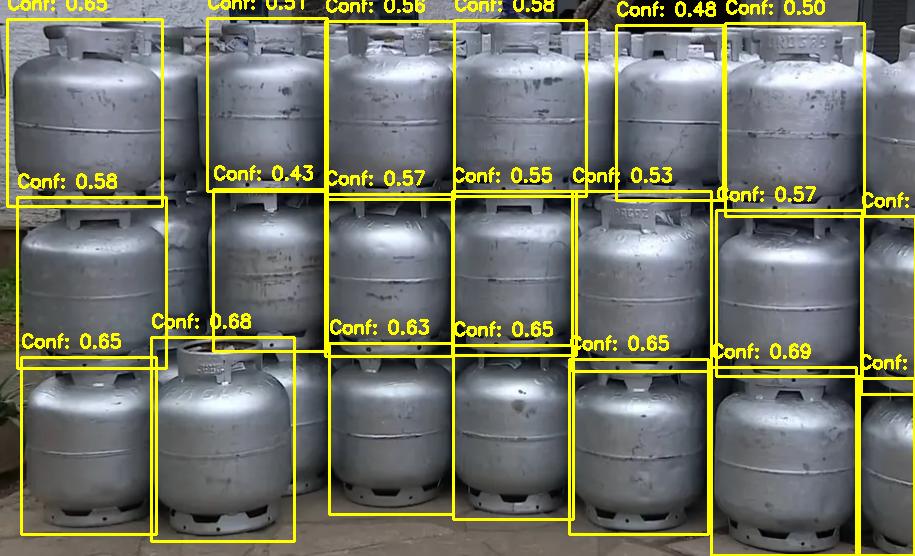


=== Resumo da Detecção ===
Total de objetos detectados: 20

Resultados salvos em:
- Imagem: detection_results/detected_20250212_221244.jpg
- Dados: detection_results/detections_20250212_221244.json


In [5]:
from inference_sdk import InferenceHTTPClient
import cv2
import numpy as np
from datetime import datetime
import os
import json
from google.colab.patches import cv2_imshow

class SimpleObjectDetector:
    def __init__(self, api_key: str, api_url: str = "https://detect.roboflow.com"):
        self.client = InferenceHTTPClient(api_url=api_url, api_key=api_key)

    def load_image(self, image_path: str) -> np.ndarray:
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Erro: Não foi possível carregar a imagem em {image_path}")
        return image

    def detect_objects(self, image: np.ndarray, model_id: str) -> list:
        temp_path = "temp_image.jpg"
        cv2.imwrite(temp_path, image)

        try:
            result = self.client.infer(temp_path, model_id=model_id)
            return result["predictions"]
        except Exception as e:
            print(f"Erro durante a detecção: {str(e)}")
            return []
        finally:
            if os.path.exists(temp_path):
                os.remove(temp_path)

    def draw_detections(self, image: np.ndarray, predictions: list) -> np.ndarray:
        detected_objects = []

        # Ordena as detecções por confiança (decrescente)
        predictions = sorted(predictions, key=lambda x: x["confidence"], reverse=True)

        for prediction in predictions:
            confidence = prediction["confidence"]

            if confidence < 0.4:
                continue  # Ignora detecções com confiança inferior a 0.4

            x = int(prediction["x"])
            y = int(prediction["y"])
            width = int(prediction["width"])
            height = int(prediction["height"])

            x1, y1 = max(0, int(x - width / 2)), max(0, int(y - height / 2))
            x2, y2 = min(image.shape[1], int(x + width / 2)), min(image.shape[0], int(y + height / 2))

            # Define a cor com base na confiança
            # Define a cor com base na confiança
            if confidence > 0.8:
                color = (0, 255, 0)  # Verde (alta confiança)
            elif confidence > 0.4:
                color = (0, 255, 255)  # Amarelo (média confiança 0.4 - 0.8)
            else:
                color = (0, 0, 255)  # Vermelho (confiança < 0.4)

            # Desenha contorno da bounding box
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

            # Rótulo de confiança
            label = f"Conf: {confidence:.2f}"
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            # Adiciona à lista de objetos detectados
            detected_objects.append({"confidence": confidence, "bbox": (x1, y1, x2, y2)})

        return image, detected_objects

    def process_image(self, image_path: str, model_id: str) -> dict:
        try:
            original_image = self.load_image(image_path)
            predictions = self.detect_objects(original_image, model_id)
            result_image, detections = self.draw_detections(original_image.copy(), predictions)

            # Salva a imagem processada
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_dir = "detection_results"
            os.makedirs(output_dir, exist_ok=True)

            output_path = os.path.join(output_dir, f"detected_{timestamp}.jpg")
            cv2.imwrite(output_path, result_image)

            # Salva os dados das detecções
            data_path = os.path.join(output_dir, f"detections_{timestamp}.json")
            with open(data_path, 'w') as f:
                json.dump({'total_detections': len(detections), 'detections': detections, 'image_size': original_image.shape[:2]}, f, indent=4)

            return {"image": result_image, "summary": {"total_detections": len(detections), "output_path": output_path, "data_path": data_path}}

        except Exception as e:
            raise Exception(f"Erro ao processar a imagem: {str(e)}")

def main():
    API_KEY = "1uaBIxC6yfhPjoHi8YF3"
    MODEL_ID = "garrafas-khs2q/1"
    IMAGE_PATH = "/content/fswefsdf.png"

    detector = SimpleObjectDetector(api_key=API_KEY)

    try:
        result = detector.process_image(image_path=IMAGE_PATH, model_id=MODEL_ID)

        cv2_imshow(result["image"])  # Exibe a imagem processada

        print("\n=== Resumo da Detecção ===")
        print(f"Total de objetos detectados: {result['summary']['total_detections']}")

        if result["summary"]["output_path"]:
            print(f"\nResultados salvos em:")
            print(f"- Imagem: {result['summary']['output_path']}")
            print(f"- Dados: {result['summary']['data_path']}")

    except Exception as e:
        print(f"Erro: {str(e)}")

if __name__ == "__main__":
    main()


[LOG] 2025-02-12 22:12:44 - Carregando imagem: /content/fswefsdf.png
[LOG] 2025-02-12 22:12:44 - Enviando imagem para inferência...


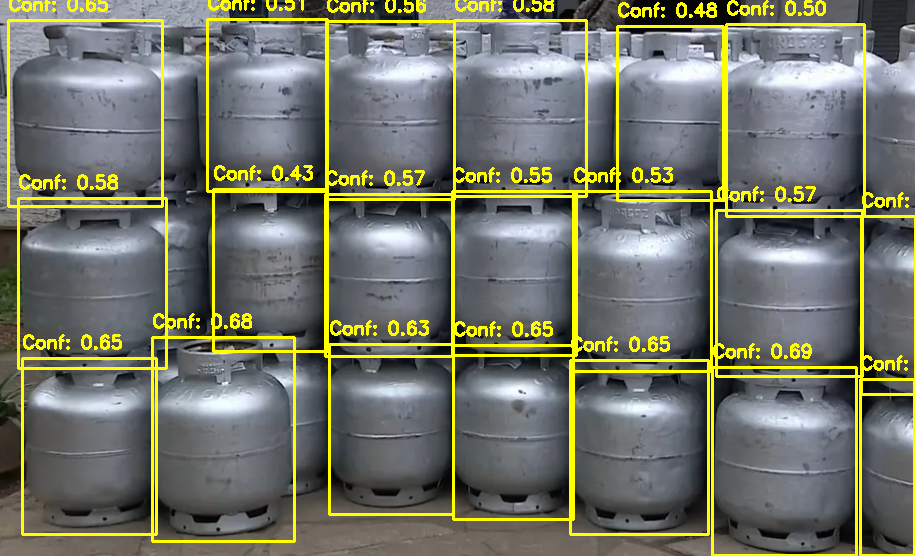


=== Resultados para /content/fswefsdf.png ===
Total de objetos detectados: 20
Imagem salva em: detection_results/detected_20250212_221244.jpg
Dados salvos em: detection_results/detections_20250212_221244.json


In [6]:
from inference_sdk import InferenceHTTPClient
import cv2
import numpy as np
from datetime import datetime
import os
import json
from google.colab.patches import cv2_imshow

class SimpleObjectDetector:
    def __init__(self, api_key: str, model_id: str, api_url: str = "https://detect.roboflow.com", confidence_threshold=0.4, min_object_size=20, debug=False):
        self.client = InferenceHTTPClient(api_url=api_url, api_key=api_key)
        self.model_id = model_id
        self.confidence_threshold = confidence_threshold
        self.min_object_size = min_object_size
        self.debug = debug

    def log(self, message: str):
        if self.debug:
            print(f"[LOG] {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} - {message}")

    def load_image(self, image_path: str) -> np.ndarray:
        self.log(f"Carregando imagem: {image_path}")
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Erro: Não foi possível carregar a imagem em {image_path}")
        return image

    def detect_objects(self, image: np.ndarray) -> list:
        temp_path = "temp_image.jpg"
        cv2.imwrite(temp_path, image)

        try:
            self.log("Enviando imagem para inferência...")
            result = self.client.infer(temp_path, model_id=self.model_id)
            return result.get("predictions", [])
        except Exception as e:
            print(f"Erro durante a detecção: {str(e)}")
            return []
        finally:
            if os.path.exists(temp_path):
                os.remove(temp_path)

    def draw_detections(self, image: np.ndarray, predictions: list) -> np.ndarray:
        detected_objects = []
        predictions = sorted(predictions, key=lambda x: x["confidence"], reverse=True)

        for prediction in predictions:
            confidence = prediction["confidence"]
            if confidence < self.confidence_threshold:
                continue  # Ignora baixa confiança

            x, y, width, height = map(int, [prediction["x"], prediction["y"], prediction["width"], prediction["height"]])
            if width < self.min_object_size or height < self.min_object_size:
                continue  # Ignora objetos muito pequenos

            x1, y1, x2, y2 = max(0, x - width // 2), max(0, y - height // 2), min(image.shape[1], x + width // 2), min(image.shape[0], y + height // 2)

            color = (0, 255, 0) if confidence > 0.8 else (0, 255, 255) if confidence > 0.4 else (0, 0, 255)
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
            cv2.putText(image, f"Conf: {confidence:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            detected_objects.append({"confidence": confidence, "bbox": (x1, y1, x2, y2)})

        return image, detected_objects

    def process_image(self, image_path: str) -> dict:
        try:
            original_image = self.load_image(image_path)
            predictions = self.detect_objects(original_image)
            result_image, detections = self.draw_detections(original_image.copy(), predictions)

            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_dir = "detection_results"
            os.makedirs(output_dir, exist_ok=True)

            output_path = os.path.join(output_dir, f"detected_{timestamp}.jpg")
            cv2.imwrite(output_path, result_image)

            data_path = os.path.join(output_dir, f"detections_{timestamp}.json")
            with open(data_path, 'w') as f:
                json.dump({'total_detections': len(detections), 'detections': detections, 'image_size': original_image.shape[:2]}, f, indent=4)

            return {"image": result_image, "summary": {"total_detections": len(detections), "output_path": output_path, "data_path": data_path}}

        except Exception as e:
            raise Exception(f"Erro ao processar a imagem: {str(e)}")

    def process_multiple_images(self, image_paths: list):
        results = {}
        for image_path in image_paths:
            try:
                results[image_path] = self.process_image(image_path)
            except Exception as e:
                print(f"Erro ao processar {image_path}: {str(e)}")
        return results


def main():
    API_KEY = "1uaBIxC6yfhPjoHi8YF3"
    MODEL_ID = "garrafas-khs2q/1"
    IMAGE_PATHS = ["/content/fswefsdf.png"]  # Lista de imagens para processar

    detector = SimpleObjectDetector(api_key=API_KEY, model_id=MODEL_ID, confidence_threshold=0.4, min_object_size=20, debug=True)

    results = detector.process_multiple_images(IMAGE_PATHS)

    for img_path, result in results.items():
        cv2_imshow(result["image"])
        print(f"\n=== Resultados para {img_path} ===")
        print(f"Total de objetos detectados: {result['summary']['total_detections']}")
        print(f"Imagem salva em: {result['summary']['output_path']}")
        print(f"Dados salvos em: {result['summary']['data_path']}")

if __name__ == "__main__":
    main()


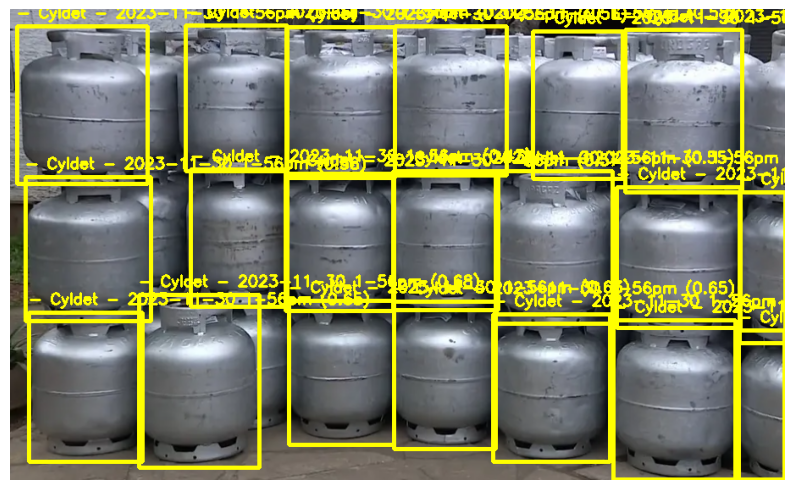


=== Resumo da Detecção ===
Total de objetos detectados: 20
Imagem salva em: detection_results/detected_20250212_221244.jpg
Dados salvos em: detection_results/detections_20250212_221244.json


In [7]:
from inference_sdk import InferenceHTTPClient
import cv2
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from datetime import datetime
from google.colab.patches import cv2_imshow

class AdvancedObjectDetector:
    def __init__(self, api_key: str, api_url: str = "https://detect.roboflow.com"):
        self.client = InferenceHTTPClient(api_url=api_url, api_key=api_key)

    def load_image(self, image_path: str) -> np.ndarray:
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Erro: Não foi possível carregar a imagem em {image_path}")
        return image

    def detect_objects(self, image: np.ndarray, model_id: str) -> list:
        temp_path = "temp_image.jpg"
        cv2.imwrite(temp_path, image)

        try:
            result = self.client.infer(temp_path, model_id=model_id)
            return result.get("predictions", [])
        except Exception as e:
            print(f"Erro durante a detecção: {str(e)}")
            return []
        finally:
            if os.path.exists(temp_path):
                os.remove(temp_path)

    def draw_detections(self, image: np.ndarray, predictions: list) -> np.ndarray:
        detected_objects = []
        predictions = sorted(predictions, key=lambda x: x["confidence"], reverse=True)

        for prediction in predictions:
            confidence = prediction["confidence"]
            if confidence < 0.4:
                continue

            x, y = int(prediction["x"]), int(prediction["y"])
            width, height = int(prediction["width"]), int(prediction["height"])
            x1, y1 = max(0, x - width // 2), max(0, y - height // 2)
            x2, y2 = min(image.shape[1], x + width // 2), min(image.shape[0], y + height // 2)

            # Gradiente de confiança
            if confidence > 0.8:
                color = (0, 255, 0)  # Verde
            elif confidence >= 0.4:
                color = (0, 255, 255)  # Amarelo
            else:
                color = (0, 0, 255)  # Vermelho

            cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)
            label = f"{prediction.get('class', 'Objeto')} ({confidence:.2f})"
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

            detected_objects.append({"class": prediction.get('class', 'Objeto'), "confidence": confidence, "bbox": (x1, y1, x2, y2)})

        return image, detected_objects

    def process_image(self, image_path: str, model_id: str) -> dict:
        try:
            original_image = self.load_image(image_path)
            predictions = self.detect_objects(original_image, model_id)
            result_image, detections = self.draw_detections(original_image.copy(), predictions)

            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_dir = "detection_results"
            os.makedirs(output_dir, exist_ok=True)

            output_path = os.path.join(output_dir, f"detected_{timestamp}.jpg")
            data_path = os.path.join(output_dir, f"detections_{timestamp}.json")

            cv2.imwrite(output_path, result_image)
            with open(data_path, 'w') as f:
                json.dump({'total_detections': len(detections), 'detections': detections, 'image_size': original_image.shape[:2]}, f, indent=4)

            return {"image": result_image, "summary": {"total_detections": len(detections), "output_path": output_path, "data_path": data_path}}

        except Exception as e:
            raise Exception(f"Erro ao processar a imagem: {str(e)}")

    def show_image(self, image: np.ndarray):
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

def main():
    API_KEY = "1uaBIxC6yfhPjoHi8YF3"
    MODEL_ID = "garrafas-khs2q/1"
    IMAGE_PATH = "/content/fswefsdf.png"

    detector = AdvancedObjectDetector(api_key=API_KEY)

    try:
        result = detector.process_image(image_path=IMAGE_PATH, model_id=MODEL_ID)
        detector.show_image(result["image"])  # Exibe a imagem processada com Matplotlib

        print("\n=== Resumo da Detecção ===")
        print(f"Total de objetos detectados: {result['summary']['total_detections']}")
        print(f"Imagem salva em: {result['summary']['output_path']}")
        print(f"Dados salvos em: {result['summary']['data_path']}")
    except Exception as e:
        print(f"Erro: {str(e)}")

if __name__ == "__main__":
    main()

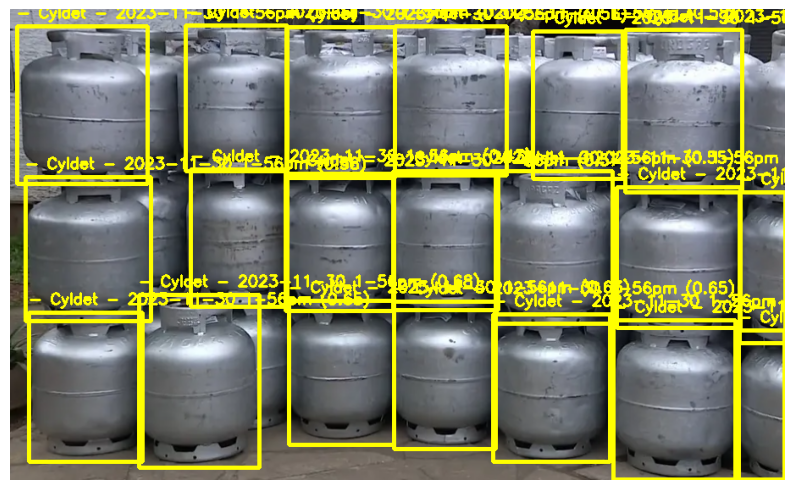


=== Resumo da Detecção ===
Total de objetos detectados: 20
Imagem salva em: detection_results/detected_20250212_221318.jpg
Dados salvos em: detection_results/detections_20250212_221318.json
Erro: name 'VIDEO_PATH' is not defined


In [9]:
from inference_sdk import InferenceHTTPClient
import cv2
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from datetime import datetime
from google.colab.patches import cv2_imshow
from concurrent.futures import ThreadPoolExecutor
import threading

class AdvancedObjectDetector:
    def __init__(self, api_key: str, api_url: str = "https://detect.roboflow.com"):
        self.client = InferenceHTTPClient(api_url=api_url, api_key=api_key)
        self.lock = threading.Lock()  # Para garantir thread-safety em operações concorrentes

    def load_image(self, image_path: str) -> np.ndarray:
        """Carrega uma imagem do disco."""
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Erro: Arquivo não encontrado em {image_path}")
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Erro: Não foi possível carregar a imagem em {image_path}")
        return image

    def detect_objects(self, image: np.ndarray, model_id: str) -> list:
        """Realiza a inferência usando o modelo especificado."""
        temp_path = f"temp_image_{threading.get_ident()}.jpg"
        try:
            cv2.imwrite(temp_path, image)
            result = self.client.infer(temp_path, model_id=model_id)
            return result.get("predictions", [])
        except Exception as e:
            print(f"Erro durante a detecção: {str(e)}")
            return []
        finally:
            if os.path.exists(temp_path):
                os.remove(temp_path)

    def draw_detections(self, image: np.ndarray, predictions: list, confidence_threshold: float = 0.4) -> tuple:
        """Desenha caixas delimitadoras e rótulos nas detecções."""
        detected_objects = []
        for prediction in predictions:
            confidence = prediction["confidence"]
            if confidence < confidence_threshold:
                continue
            x, y = int(prediction["x"]), int(prediction["y"])
            width, height = int(prediction["width"]), int(prediction["height"])
            x1, y1 = max(0, x - width // 2), max(0, y - height // 2)
            x2, y2 = min(image.shape[1], x + width // 2), min(image.shape[0], y + height // 2)

            # Gradiente de confiança
            color = (0, 255, 0) if confidence > 0.8 else (0, 255, 255) if confidence >= 0.4 else (0, 0, 255)
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 3)
            label = f"{prediction.get('class', 'Objeto')} ({confidence:.2f})"
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            detected_objects.append({
                "class": prediction.get('class', 'Objeto'),
                "confidence": confidence,
                "bbox": (x1, y1, x2, y2)
            })
        return image, detected_objects

    def process_image(self, image_path: str, model_id: str, confidence_threshold: float = 0.4) -> dict:
        """Processa uma única imagem e salva os resultados."""
        try:
            original_image = self.load_image(image_path)
            predictions = self.detect_objects(original_image, model_id)
            result_image, detections = self.draw_detections(original_image.copy(), predictions, confidence_threshold)

            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            output_dir = "detection_results"
            os.makedirs(output_dir, exist_ok=True)

            output_path = os.path.join(output_dir, f"detected_{timestamp}.jpg")
            data_path = os.path.join(output_dir, f"detections_{timestamp}.json")

            cv2.imwrite(output_path, result_image)
            with open(data_path, 'w') as f:
                json.dump({
                    'total_detections': len(detections),
                    'detections': detections,
                    'image_size': original_image.shape[:2]
                }, f, indent=4)

            return {
                "image": result_image,
                "summary": {
                    "total_detections": len(detections),
                    "output_path": output_path,
                    "data_path": data_path
                }
            }
        except Exception as e:
            raise Exception(f"Erro ao processar a imagem: {str(e)}")

    def process_video(self, video_path: str, model_id: str, output_path: str, confidence_threshold: float = 0.4):
        """Processa um vídeo frame a frame."""
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Erro: Não foi possível abrir o vídeo em {video_path}")

        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        frame_count = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_count += 1
            print(f"Processando frame {frame_count}...")
            predictions = self.detect_objects(frame, model_id)
            result_frame, _ = self.draw_detections(frame, predictions, confidence_threshold)
            out.write(result_frame)

        cap.release()
        out.release()
        print(f"Vídeo processado e salvo em {output_path}")

    def show_image(self, image: np.ndarray):
        """Exibe uma imagem usando Matplotlib."""
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

def main():
    API_KEY = "1uaBIxC6yfhPjoHi8YF3"
    MODEL_ID = "garrafas-khs2q/1"
    IMAGE_PATH = "/content/fswefsdf.png"
    # VIDEO_PATH = "/content/video.mp4"
    # OUTPUT_VIDEO_PATH = "/content/output_video.mp4"

    detector = AdvancedObjectDetector(api_key=API_KEY)

    try:
        # Processamento de imagem
        result = detector.process_image(image_path=IMAGE_PATH, model_id=MODEL_ID)
        detector.show_image(result["image"])
        print("\n=== Resumo da Detecção ===")
        print(f"Total de objetos detectados: {result['summary']['total_detections']}")
        print(f"Imagem salva em: {result['summary']['output_path']}")
        print(f"Dados salvos em: {result['summary']['data_path']}")

        # Processamento de vídeo
        detector.process_video(video_path=VIDEO_PATH, model_id=MODEL_ID, output_path=OUTPUT_VIDEO_PATH)
    except Exception as e:
        print(f"Erro: {str(e)}")

if __name__ == "__main__":
    main()

In [8]:
# Instalação das dependências necessárias
!pip install inference-sdk opencv-python-headless numpy matplotlib